<font color='blue'> **Polynomial and  least squares** </font>  

In [38]:
import numpy  as np   ; from pathlib import Path   ; import matplotlib.pyplot as plt  ; import pandas as pd  ; from scipy.optimize import curve_fit
from scipy.linalg import lstsq                     ; from scipy.optimize import least_squares       ;  import os    ; import seaborn as sns

,id2,Measured,Modelled
0,1,-1.607719,-16.07719
1,2,-5.000000,-10.43885


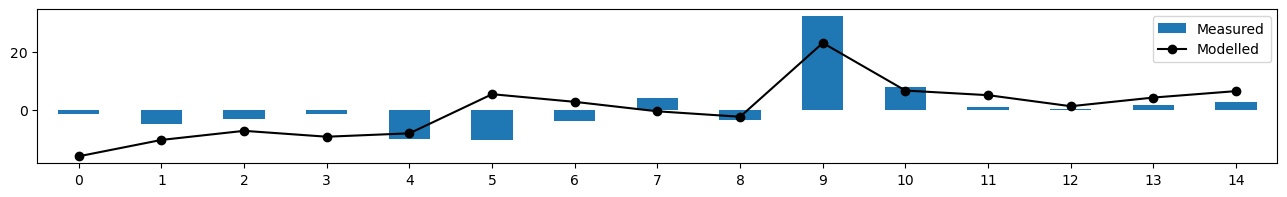

In [39]:
DATA = os.path.join(os.getcwd(), 'D_Data.csv')       ; b1=pd.read_csv(DATA)                  ; b1.head(22); b2=b1.drop('Unnamed: 0',axis=1) 

b3=b2['Group'].value_counts() ; b4=pd.DataFrame(b3)   ; b5=b4.drop('head')                   ; L1=b5.index.to_list() 
L2=b2[b2['Group'].isin(L1)]   ; L3 = L2.reset_index() ; L4 = L3.drop(L3.columns[1], axis=1)  ; L5=L4.iloc[:,:-9]  ; L5.insert(0,'id2',range(1,len(L5)+1)) 

ax=L5.plot(y=['Measured'],kind='bar',use_index=False,figsize=(16, 2))       ; L5.plot(y=['Modelled'],linestyle='-',marker='o',color='black',ax=ax) 
XX=L5['id2']   ; MED=L5['Measured'] ;MOD = L5['Modelled']                   ; L5[['id2','Measured','Modelled']].head(2)

<font color='black'> **Objective function:** 
<font color='blue'> 
$ 
\,\,\,\,\,\,\,      \Phi=\sum_{i=1}^{NPAR}\left(y_{i}-m\left(x_{i}\right)\right)^{2}              \,\,\,\,\,\,\,\,\,\,\,\,\,\,
$
<font color='red'> 
$ 
\,\,\,\,\,\,\,      \Phi=\left(\mathbf{y}-\mathbf{m}\right)^{T}\left(\mathbf{y}-\mathbf{m}\right)               \,\,\,\,\,\,\,\,\,\,\,\,\,\,
$

In [40]:
y = L5['Measured'] ; m = L5['Modelled']    ;OBJ=np.sum(np.square(y-m))       ; PHI = np.dot((y-m).T,(y-m))      ;print('PHI:'      ,int(PHI)   ,'__i.e__',int(OBJ)) 

PHI: 768 __i.e__ 768


popt: [-6.83997697e+04  9.96581322e-06  6.83993284e+04]   MAX: 8.160346825838623e+27
SS(phi): 1500.6727498782222


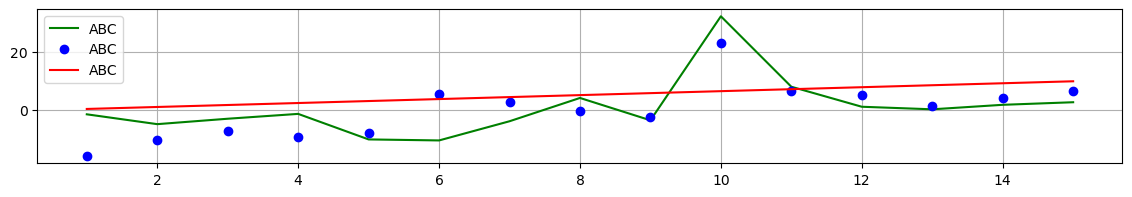

In [41]:
def func(x, a, b, c):                      return a * np.exp(-b * x) + c        # fundamental exponential curve   

popt, pcov = curve_fit(func, MED, MOD,)                      
plt.figure(figsize=(14, 2))   ;plt.plot(XX,MED,'green' ,XX,MOD,'bo' , XX,func(XX,*popt),'red',label='ABC')  ; plt.grid(True);plt.legend()

print('popt:',popt,' ','MAX:',np.linalg.cond(pcov))  
SS=np.sum(np.square(L5['Measured'] - func(XX, *popt))); print('SS(phi):', SS)                   

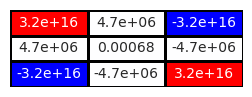

In [42]:
fig = plt.figure(figsize=(3,1))  
ax1 = fig.add_subplot(111) ; sns.heatmap(pcov  ,annot=True, cmap='bwr', cbar=False, linewidths=1, linecolor='black') ;plt.axis('off') ; plt.show()

In [43]:
perr= np.sqrt(np.diag(pcov))                               ; print(f"Parameter a: {popt[0]:.4f} ± {perr[0]:.4f}") 
print(f"Parameter b: {popt[1]:.4f} ± {perr[1]:.4f}")       ; print(f"Parameter c: {popt[2]:.4f} ± {perr[2]:.4f}")

Parameter a: -68399.7697 ± 178797176.6725
Parameter b: 0.0000 ± 0.0261
Parameter c: 68399.3284 ± 178797176.4584


In [44]:
OPT=pd.DataFrame(popt[0]*np.exp(-popt[1] * XX)+popt[2])  ;L6= pd.concat([L5[:],OPT[:]],axis=1)  ; L6.rename(columns={ L6.columns[7]: "Optimal" }).tail(4)

,Optimal,level_0,id,Observation,Group,Measured,Modelled,Optimal
11,12,14,15,ch1,const_head,1.000000,4.990921,7.738151
12,13,15,16,ch2,const_head,0.118361,1.183609,8.419725
13,14,16,17,ch3,const_head,1.669406,4.173516,9.101293
14,15,17,18,ch4,const_head,2.557503,6.393757,9.782853


In [45]:
MED = L5[['id2','Measured']].to_numpy()  ; MOD = L5[['id2','Modelled']].to_numpy()         

sol, residuals, rank, s = lstsq(MED, MOD)           ; print(sol,", ______residuals:", residuals , "______rank:", rank, "______s:", s)     #  lstsq =  # MIN | 𝐀 @ 𝐱 − 𝐛 |

[[ 1.00000000e+00  1.76385182e-01]
 [-1.94589022e-16  6.39408859e-01]] , ______residuals: [1.35000923e-29 5.86485955e+02] ______rank: 2 ______s: [40.63803987 31.64098237]
